# **Code**

In [1]:
print("Connecting to Google Drive...")
from google.colab import drive
drive.mount('/content/drive')
print("Drive connected.")

Connecting to Google Drive...
Mounted at /content/drive
Drive connected.


In [2]:
!pip install rasterio pandas

import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import Window
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [3]:
full_image_path = '/content/drive/My Drive/Internship_project/Singrauli_Merged_Image.tif'

points_csv_path = '/content/drive/My Drive/Internship_project/Singrauli.csv'

processed_data_path = '/content/drive/My Drive/Internship_project/cnn_prepared_patches_9.npz'

PATCH_SIZE = 9

In [4]:
def create_patch_dataset(image_path, csv_path, patch_size):
    """
    Uses a CSV of point coordinates to extract image patches from a large GeoTIFF.

    Returns:
        A tuple of (numpy.ndarray, numpy.ndarray): (image_patches, labels)
    """
    try:
        points_df = pd.read_csv(csv_path)
        src_image = rasterio.open(image_path)
    except FileNotFoundError as e:
        print(f"ERROR: A file was not found. Please check your paths. Details: {e}")
        return None, None

    print(f"Loaded {len(points_df)} training point locations.")
    print(f"Image has {src_image.count} bands.")

    X_patches = []
    y_labels = []

    print(f"\nExtracting {patch_size}x{patch_size} patches... (This can be slow)")

    for index, row in points_df.iterrows():
        try:
            lon = row['longitude']
            lat = row['latitude']
            label = row['class']

            py, px = src_image.index(lon, lat)

            window = Window(px - patch_size // 2, py - patch_size // 2, patch_size, patch_size)

            patch = src_image.read(window=window)

            if patch.shape[1] == patch_size and patch.shape[2] == patch_size:
                patch = np.moveaxis(patch, 0, -1)

                X_patches.append(patch)
                y_labels.append(label)

        except Exception:
            pass

    src_image.close()
    print(f"\nSuccessfully extracted {len(X_patches)} valid patches.")

    return np.array(X_patches), np.array(y_labels)

In [5]:
X_data, y_data = create_patch_dataset(full_image_path, points_csv_path, PATCH_SIZE)

if X_data is not None and X_data.shape[0] > 0:
    print(f"\nSaving {X_data.shape[0]} patches to a compressed NPZ file...")
    np.savez_compressed(processed_data_path, x_data=X_data, y_data=y_data)
    print(f"✅ Data successfully saved to: {processed_data_path}")
else:
    print("No valid patches were extracted, so no file was saved.")

Loaded 123418 training point locations.
Image has 11 bands.

Extracting 9x9 patches... (This can be slow)

Successfully extracted 123418 valid patches.

Saving 123418 patches to a compressed NPZ file...
✅ Data successfully saved to: /content/drive/My Drive/Internship_project/cnn_prepared_patches_9.npz



Loading data from: /content/drive/My Drive/Internship_project/cnn_prepared_patches_9.npz

--- File Contents Summary ---
Arrays found in file: ['x_data', 'y_data']
Shape of image patches array ('x_data'): (123418, 9, 9, 11)
Shape of labels array ('y_data'): (123418,)
-----------------------------

Displaying a few sample patches from the dataset...



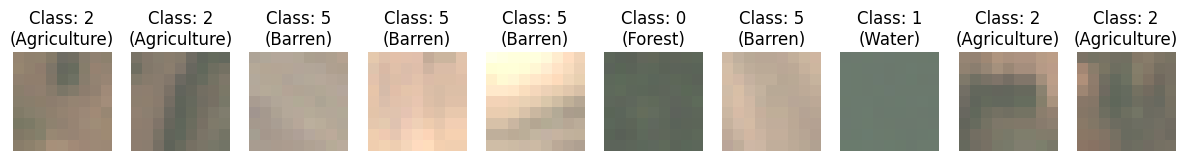

In [6]:

try:
    print(f"\nLoading data from: {processed_data_path}")
    data = np.load(processed_data_path)

    print("\n--- File Contents Summary ---")
    print(f"Arrays found in file: {data.files}")

    X_data = data['x_data']
    y_data = data['y_data']

    print(f"Shape of image patches array ('x_data'): {X_data.shape}")
    print(f"Shape of labels array ('y_data'): {y_data.shape}")
    print("-----------------------------\n")
    print("Displaying a few sample patches from the dataset...\n")

    class_names = [
        'Forest',       # 0
        'Water',        # 1
        'Agriculture',  # 2
        'Settlement',   # 3
        'Mining',       # 4
        'Barren'        # 5
    ]

    def normalize_for_display(patch):
        red = patch[:, :, 2] # B4 is the 3rd band
        green = patch[:, :, 1] # B3 is the 2nd band
        blue = patch[:, :, 0] # B2 is the 1st band

        rgb = np.dstack((red, green, blue))

        rgb_scaled = (rgb / 4000.0).astype(np.float32)
        return np.clip(rgb_scaled, 0, 1)

    plt.figure(figsize=(15, 7))
    num_samples_to_show = 10
    for i in range(num_samples_to_show):
        idx = np.random.randint(0, len(X_data))

        image_patch = X_data[idx]
        label_id = y_data[idx]

        display_patch = normalize_for_display(image_patch)

        ax = plt.subplot(1, num_samples_to_show, i + 1)
        plt.imshow(display_patch)
        plt.title(f"Class: {label_id}\n({class_names[label_id]})")
        plt.axis("off")

    plt.show()

except FileNotFoundError:
    print(f"\nERROR: The file was not found at '{processed_data_path}'.")
    print("Please check the path and make sure the file exists.")
except Exception as e:
    print(f"An error occurred: {e}")